# Elexon day-ahead solar forecast test

This notebook does two things:

1. fetches a 7-day block of day-ahead solar forecast data from Elexon,
2. cleans it into a simple hourly capacity-factor profile that can later feed `Simulator`.

The preprocessing is kept explicit and small so it can be moved into the class later.

In [2]:
import json
import os
import urllib.error
import urllib.parse
import urllib.request

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

API_BASE_URL = "https://data.elexon.co.uk/bmrs/api/v1/forecast/generation/wind-and-solar/day-ahead"

# Define functions to build request
def build_headers() -> dict[str, str]:
    """Build request headers for the Elexon API."""
    headers = {"Accept": "application/json"}
    api_key = os.getenv("ELEXON_API_KEY")
    api_header = os.getenv("ELEXON_API_HEADER", "Authorization")
    if api_key:
        if api_header.lower() == "authorization":
            headers[api_header] = f"Bearer {api_key}"
        else:
            headers[api_header] = api_key
    return headers


def fetch_elexon_json(base_url: str, params: dict[str, object], headers: dict[str, str] | None = None, timeout: int = 60) -> dict:
    """Fetch JSON from the Elexon API and return the decoded payload."""
    query_string = urllib.parse.urlencode(params)
    request_url = f"{base_url}?{query_string}"
    request = urllib.request.Request(request_url, headers=headers or build_headers())

    try:
        with urllib.request.urlopen(request, timeout=timeout) as response:
            payload = response.read().decode("utf-8")
    except urllib.error.HTTPError as exc:
        raise RuntimeError(f"Elexon request failed with HTTP {exc.code}: {exc.reason}") from exc
    except urllib.error.URLError as exc:
        raise RuntimeError(f"Elexon request failed: {exc.reason}") from exc

    return json.loads(payload)



### Data fetching

In [3]:
# Define the time window for the forecast request
# Use a completed historical week. The endpoint supports up to 7 days of output.
forecast_end = pd.Timestamp.utcnow().normalize() - pd.Timedelta(days=1)
forecast_start = forecast_end - pd.Timedelta(days=6)

# Build the request parameters
params = {
    "from": forecast_start.date().isoformat(),
    "to": forecast_end.date().isoformat(),
    "processType": "day ahead",
    "format": "json",
}

print("Request window:", params["from"], "to", params["to"])
print("Request URL:", f"{API_BASE_URL}?{urllib.parse.urlencode(params)}")

Request window: 2026-07-08 to 2026-07-14
Request URL: https://data.elexon.co.uk/bmrs/api/v1/forecast/generation/wind-and-solar/day-ahead?from=2026-07-08&to=2026-07-14&processType=day+ahead&format=json


In [ ]:
# Now fetch the data from the Elexon API
payload = fetch_elexon_json(API_BASE_URL, params)

# Visualize the structure of the returned payload
print("Top-level keys:", list(payload.keys()))
print("Metadata:", payload.get("metadata", {}))
print("Number of raw records:", len(payload.get("data", [])))

# Convert the raw data into a pandas DataFrame for easier analysis
raw_df = pd.DataFrame(payload["data"])
display(raw_df.head(10))
print("\nColumns:", raw_df.columns.tolist())

Top-level keys: ['metadata', 'data']
Metadata: {'datasets': ['DGWS']}
Number of raw records: 867


,publishTime,processType,businessType,psrType,startTime,settlementDate,settlementPeriod,quantity
0,2026-07-13T16:45:01Z,Day ahead,Solar generation,Solar,2026-07-14T00:00:00Z,2026-07-14,3,0.0
1,2026-07-13T16:45:01Z,Day ahead,Wind generation,Wind Offshore,2026-07-14T00:00:00Z,2026-07-14,3,6487.0
2,2026-07-13T16:45:01Z,Day ahead,Wind generation,Wind Onshore,2026-07-14T00:00:00Z,2026-07-14,3,2538.0
3,2026-07-12T16:45:02Z,Day ahead,Solar generation,Solar,2026-07-13T23:30:00Z,2026-07-14,2,0.0
4,2026-07-12T16:45:02Z,Day ahead,Wind generation,Wind Offshore,2026-07-13T23:30:00Z,2026-07-14,2,6870.0
5,2026-07-12T16:45:02Z,Day ahead,Wind generation,Wind Onshore,2026-07-13T23:30:00Z,2026-07-14,2,2862.0
6,2026-07-12T16:45:02Z,Day ahead,Solar generation,Solar,2026-07-13T23:00:00Z,2026-07-14,1,0.0
7,2026-07-12T16:45:02Z,Day ahead,Wind generation,Wind Offshore,2026-07-13T23:00:00Z,2026-07-14,1,7082.0
8,2026-07-12T16:45:02Z,Day ahead,Wind generation,Wind Onshore,2026-07-13T23:00:00Z,2026-07-14,1,2917.0
9,2026-07-12T16:45:02Z,Day ahead,Solar generation,Solar,2026-07-13T22:30:00Z,2026-07-13,48,0.0



Columns: ['publishTime', 'processType', 'businessType', 'psrType', 'startTime', 'settlementDate', 'settlementPeriod', 'quantity']


### Data preprocessing

In [6]:
# Check that the expected columns are present in the DataFrame
required_columns = {"businessType", "startTime", "quantity"}
missing_columns = required_columns - set(raw_df.columns)
if missing_columns:
    raise KeyError(f"The API payload is missing expected columns: {sorted(missing_columns)}")

# Filter the DataFrame to only include solar generation forecasts and process the data
solar_df = raw_df.loc[raw_df["businessType"].str.contains("solar", case=False, na=False)].copy()
# Convert columns to proper data types and drop rows with missing values
solar_df["startTime"] = pd.to_datetime(solar_df["startTime"], utc=True)
solar_df["quantity"] = pd.to_numeric(solar_df["quantity"], errors="coerce")
solar_df = solar_df.dropna(subset=["startTime", "quantity"]).sort_values("startTime")

# Resample the solar forecast data to hourly intervals and calculate the mean quantity for each hour
hourly_solar = (
    solar_df.set_index("startTime")[["quantity"]]
    .resample("H")
    .mean()
    .rename(columns={"quantity": "solar_forecast_mw"})
    .dropna()
    .reset_index()
)

C:\Users\Pc\AppData\Local\Temp\ipykernel_15328\3195689846.py:17: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("H")


Let's normalize the fetched data to obtain a capacity factor between [0, 1]

In [7]:
# For this notebook we normalise by the week peak so the profile is easy to inspect.
# Replace this with the actual site capacity when you move the logic into the simulator.
demo_solar_capacity_mw = float(hourly_solar["solar_forecast_mw"].max())
hourly_solar["capacity_factor"] = (hourly_solar["solar_forecast_mw"] / demo_solar_capacity_mw).clip(0.0, 1.0)

solar_profile = hourly_solar["capacity_factor"].to_numpy()
solar_timestamps = hourly_solar["startTime"].to_list()

display(hourly_solar.head(12))
print("\nHourly points:", len(hourly_solar))
print("Solar forecast range:", hourly_solar["startTime"].min(), "to", hourly_solar["startTime"].max())
print("Demo normalisation base (MW):", round(demo_solar_capacity_mw, 3))

,startTime,solar_forecast_mw,capacity_factor
0,2026-07-08 00:00:00+00:00,0.0,0.000000
1,2026-07-08 01:00:00+00:00,0.0,0.000000
2,2026-07-08 02:00:00+00:00,0.0,0.000000
3,2026-07-08 03:00:00+00:00,19.5,0.001299
4,2026-07-08 04:00:00+00:00,314.5,0.020958
5,2026-07-08 05:00:00+00:00,1839.5,0.122580
6,2026-07-08 06:00:00+00:00,4074.0,0.271482
7,2026-07-08 07:00:00+00:00,6713.0,0.447339
8,2026-07-08 08:00:00+00:00,9638.0,0.642255
9,2026-07-08 09:00:00+00:00,11843.0,0.789191



Hourly points: 145
Solar forecast range: 2026-07-08 00:00:00+00:00 to 2026-07-14 00:00:00+00:00
Demo normalisation base (MW): 15006.5


### Plot forecasts - visual ispection

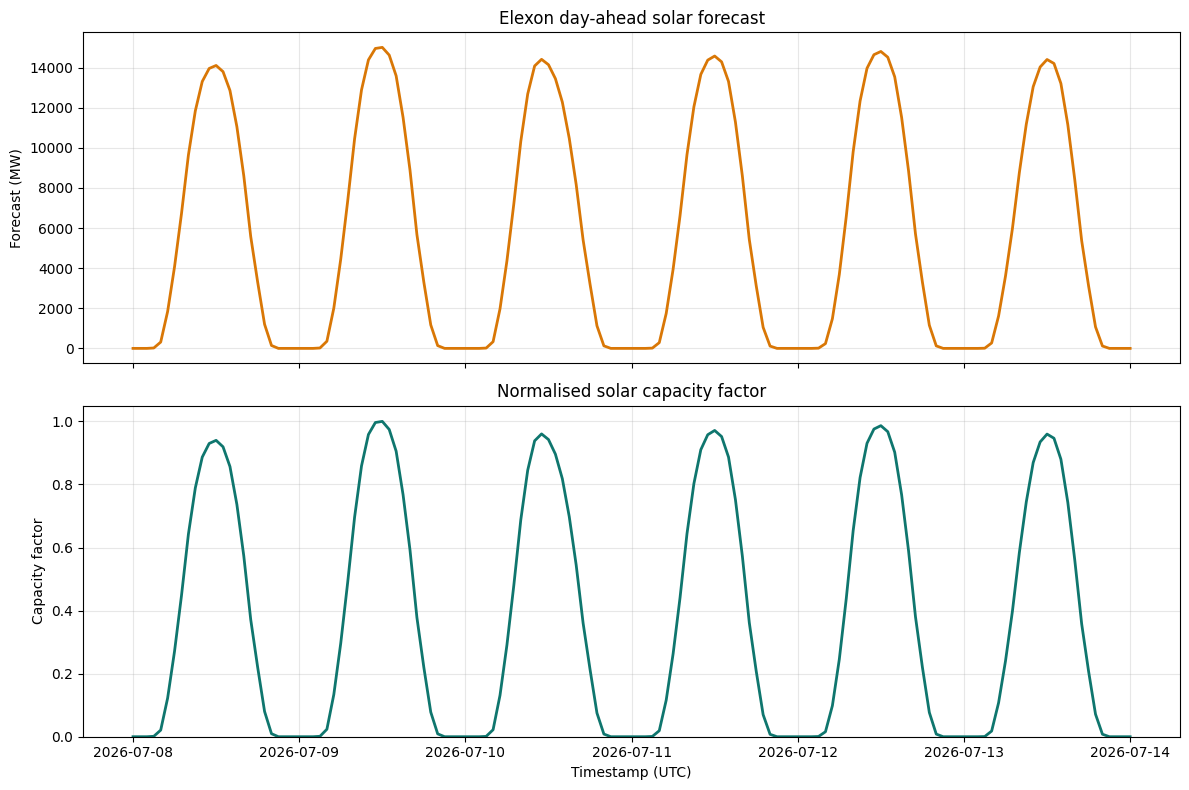

Ready for later use in Simulator:
- solar_profile shape: (145,)
- solar_timestamps length: 145


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(hourly_solar["startTime"], hourly_solar["solar_forecast_mw"], color="#d97706", linewidth=2)
axes[0].set_title("Elexon day-ahead solar forecast")
axes[0].set_ylabel("Forecast (MW)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(hourly_solar["startTime"], hourly_solar["capacity_factor"], color="#0f766e", linewidth=2)
axes[1].set_title("Normalised solar capacity factor")
axes[1].set_ylabel("Capacity factor")
axes[1].set_xlabel("Timestamp (UTC)")
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Ready for later use in Simulator:")
print("- solar_profile shape:", solar_profile.shape)
print("- solar_timestamps length:", len(solar_timestamps))

## What should move into `Simulator` later

The notebook now exposes the exact preprocessing steps that should become part of the simulator workflow later:

- build the Elexon request URL
- fetch the JSON payload
- filter the solar rows
- convert the timestamps to a regular time index
- resample to the model timestep
- normalise by the chosen solar farm capacity

When you are ready, these pieces can be wrapped into a `Simulator.fetch_forecast(...)` method or a small helper that returns the cleaned solar profile directly.